# Monthly Climate Indicators from NLDAS-3 Data (Multiprocessing Version)

This notebook processes daily NLDAS-3 data to calculate monthly Growing Degree Days (GDD), Heat Stress Days (HSD), and Frost Days using multiprocessing for parallel processing of multiple months.

Each monthly file contains all three indicators as variables:
- **gdd**: Growing Degree Days (base 10°C)
- **hsd**: Heat Stress Days (max temp > 30°C) 
- **frost_days**: Frost Days (min temp < 0°C)

Output files are named: `agroclim_indicator-YYYYMM.nc` (e.g., `agroclim_indicator-200001.nc` for January 2000)

## Memory-Efficient Version with Day-by-Day Processing

### Key Features:
1. **Day-by-Day Processing**: Processes one day at a time to minimize memory usage
2. **Full Grid Preservation**: Maintains the full 11700 x 6500 spatial dimensions
3. **Memory Management**: Uses garbage collection and memory monitoring
4. **Flexible Processing**: Can run in parallel or sequential mode

### Memory Usage:
- **Per day**: ~1-2GB (processing single day at a time)
- **Total per month**: ~3-4GB (with proper garbage collection)

### Configuration:
- Set `USE_MULTIPROCESSING = False` for sequential processing on memory-constrained systems
- Monitor memory with `verbose=True` in test cells

In [1]:
import xarray as xr
import os
import glob
import numpy as np
from datetime import datetime
import pandas as pd
from multiprocessing import Pool, cpu_count
from functools import partial
import warnings
import gc
from tqdm import tqdm
import psutil
warnings.filterwarnings('ignore')

In [2]:
# Configuration
base_data_dir = "/discover/nobackup/projects/eis_nldas3/DATA/forcing/daily"
output_dir = "./monthly_indicators"

os.makedirs(output_dir, exist_ok=True)

# Define thresholds for calculations
GDD_BASE_TEMP_C = 10    # Growing Degree Days base temperature in Celsius
HSD_THRESHOLD_C = 30    # Heat Stress Days threshold in Celsius
FROST_THRESHOLD_C = 0   # Frost Days threshold in Celsius


print(f"Base data directory: {base_data_dir}")
print(f"Output directory: {output_dir}")


Base data directory: /discover/nobackup/projects/eis_nldas3/DATA/forcing/daily
Output directory: ./monthly_indicators


In [3]:

NUM_PROCESSES = 10    # Number of multi-processes to use
SKIP_EXISTING = False  # Change to False to reprocess all files
USE_MULTIPROCESSING = True  # Set to False for sequential processing

print(f"Number of processes to use: {NUM_PROCESSES}")

Number of processes to use: 10


In [4]:
# Discover all month directories
def get_month_directories(base_dir):
    """Get all month directories (YYYYMM format) from the base directory."""
    month_dirs = []
    
    if os.path.exists(base_dir):
        for item in os.listdir(base_dir):
            item_path = os.path.join(base_dir, item)
            # Check if it's a directory and matches YYYYMM format
            if os.path.isdir(item_path) and len(item) == 6 and item.isdigit():
                month_dirs.append(item)
    
    # Sort chronologically
    month_dirs.sort()
    return month_dirs

# Get all month directories
month_directories = get_month_directories(base_data_dir)
print(f"Found {len(month_directories)} month directories")
print(f"Date range: {month_directories[0]} to {month_directories[-1]}")

Found 276 month directories
Date range: 200101 to 202312


In [5]:
# Open land water mask
mask = xr.open_dataset('gpw-land-water-mask/outputs/gpw_v4_LandWaterMask_agroclim.nc')
print(f"Mask shape: {dict(mask.dims)}")
mask

Mask shape: {'lon': 11700, 'lat': 6500}


<xarray.Dataset> Size: 304MB
Dimensions:          (lon: 11700, lat: 6500)
Coordinates:
  * lon              (lon) float32 47kB -169.0 -169.0 -169.0 ... -52.01 -52.01
  * lat              (lat) float32 26kB 7.005 7.015 7.025 ... 71.97 71.98 71.99
Data variables:
    land_water_mask  (lat, lon) float32 304MB ...
Attributes:
    CDI:          Climate Data Interface version 2.5.1 (https://mpimet.mpg.de...
    Conventions:  CF-1.8
    source:       Converted from 8 ASC tile files
    title:        GPW v4 Water Mask Data Quality Indicators - Global Mosaic
    history:      Tue Aug 19 14:06:36 2025: cdo remapnn,/Users/klesinger/Down...
    description:  Global water mask with categorical values: 0=Total Water, 1...
    CDO:          Climate Data Operators version 2.5.1 (https://mpimet.mpg.de...

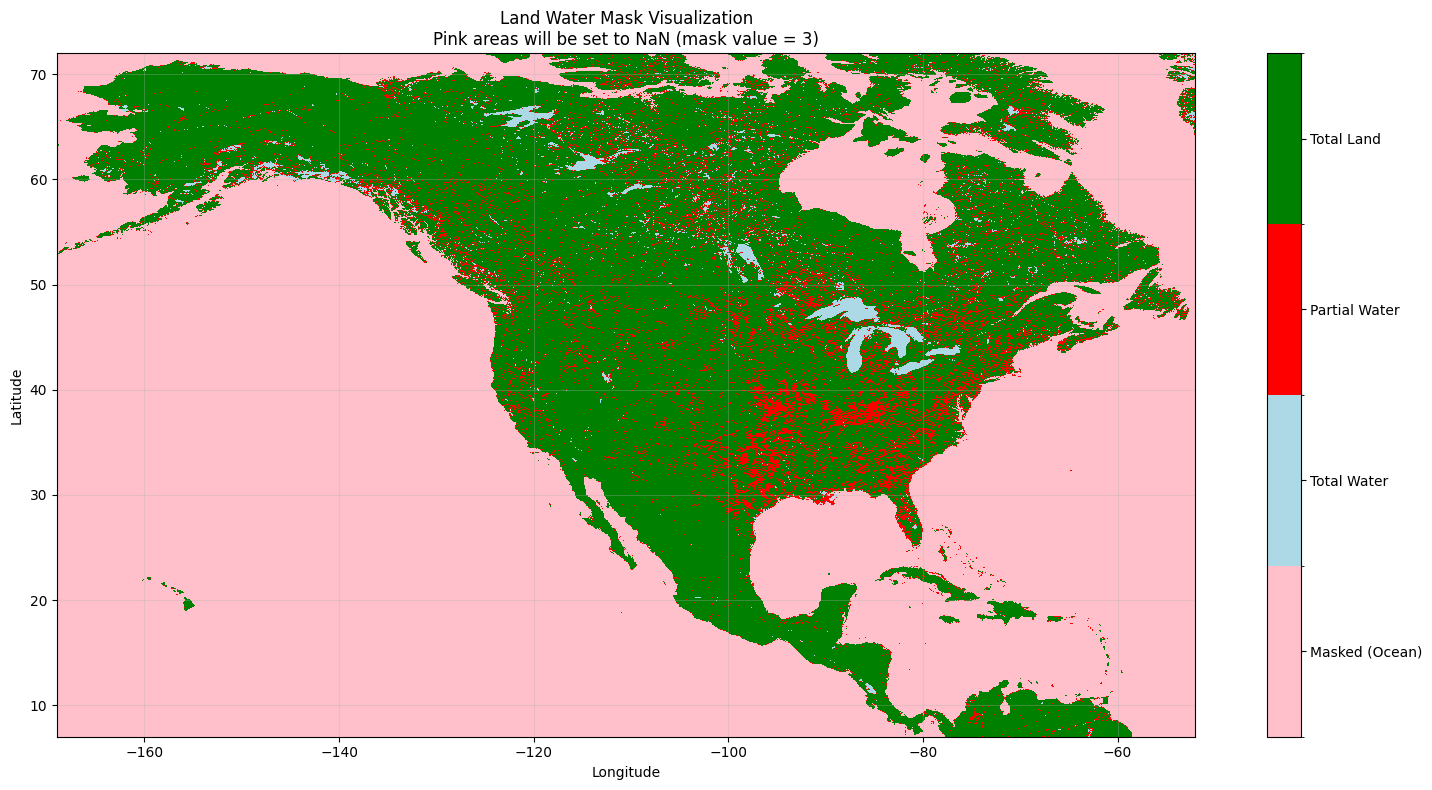

In [6]:
# Sanity check: Visualize the mask areas that will be set to NaN
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Create a figure showing the mask
fig, ax = plt.subplots(1, 1, figsize=(15, 8))

# Create a custom colormap for visualization
# 0 = Total Water -> lightblue
# 1 = Partial Water -> Blue  
# 2 = Total Land -> Green
# 3 = Ocean (will be masked) -> Pink
mask_values = mask['land_water_mask'].values
display_mask = mask_values.copy()

# Create visualization array where masked areas (0 and 3) are set to a special value
masked_areas = (mask_values == 3)
display_mask[masked_areas] = -1  # Set masked areas to -1 for pink coloring

# Create custom colormap
colors = ['pink', 'lightblue', 'red', 'green']
boundaries = [-1.5, -0.5, 0.5, 1.5, 2.5]
cmap = mcolors.ListedColormap(colors)
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

# Plot the mask
im = ax.pcolormesh(mask.lon, mask.lat, display_mask, cmap=cmap, norm=norm, shading='auto')

# Add colorbar with proper labels
cbar = plt.colorbar(im, ax=ax, ticks=[-1, 0, 1, 2])
cbar.ax.set_yticklabels(['Masked (Ocean)', 'Total Water', 'Partial Water', 'Total Land'])

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Land Water Mask Visualization\nPink areas will be set to NaN (mask value = 3)')

# Add grid
ax.grid(True, alpha=0.3)

# Set extent to focus on North America
ax.set_xlim(-169, -52)
ax.set_ylim(7, 72)

plt.tight_layout()
plt.show()

In [7]:
# Helper functions for memory monitoring and day-by-day processing
def get_memory_usage(label: str):
    """Get current memory usage in GB."""
    process = psutil.Process(os.getpid())
    mem_gb = process.memory_info().rss / 1024 / 1024 / 1024
    print(f"{label} memory usage: {mem_gb:.2f} GB")
    return mem_gb


In [8]:
def process_day_by_day(files, mask_ds):
    """
    Process dataset by opening and processing one file at a time (minimize memory).
    
    Args:
        files: List of file paths to process (one file per day)
        mask_ds: Land water mask dataset
    
    Returns:
        Dictionary with monthly indicators (gdd, hsd, frost_days) on full mask grid
    """
    
    # Open first file to get dimensions
    with xr.open_dataset(files[0]) as first_ds:
        # Align the mask to the input data coordinates using reindex_like
        # This handles small coordinate differences (e.g., -52.01 vs -52.0)
        mask_aligned = mask_ds.reindex_like(first_ds, method='nearest', tolerance=0.01)
        
        # Get the full mask
        mask_full = mask_aligned['land_water_mask']
        is_land = (mask_full == 1) | (mask_full == 2)
        is_ocean = (mask_full == 3)
        
        # Initialize accumulators on input data dimensions
        template = first_ds.isel(time=0)['Tair_min'].drop('time')
        # Explicitly use float32 for all accumulators to avoid dtype issues
        gdd_accumulator = xr.zeros_like(template, dtype='float32')
        hsd_accumulator = xr.zeros_like(template, dtype='float32') 
        frost_accumulator = xr.zeros_like(template, dtype='float32')
    
    # Process each file (day) individually
    for i, file_path in enumerate(files):
        # Open single file, process it, then close immediately
        with xr.open_dataset(file_path) as ds_day:
            # Convert temperatures to Celsius
            tasmin_C = ds_day['Tair_min'].isel(time=0) - 273.15
            tasmax_C = ds_day['Tair_max'].isel(time=0) - 273.15
            tas_C = (tasmin_C + tasmax_C) / 2
            
            # Calculate daily GDD contribution (only for non-masked areas)
            '''First xr.where statement: Anywhere where the mask condition is land (no ocean)
            Second xr.where statement: Anywhere where tas_C is > than base temp (GDD_BASE_TEMP) then return tas_C - GDD_BASE_TEMP
            else if tas_C is < than (GDD_BASE_TEMP) then return 0 for that day.
            also, if it is not a land area then make 0. (we will convert ocean to np.nan at end of script)
            '''
            gdd_daily = xr.where(is_land, 
                                xr.where(tas_C > GDD_BASE_TEMP_C, tas_C - GDD_BASE_TEMP_C, 0),
                                0)
            gdd_accumulator = gdd_accumulator + gdd_daily
            
            # Check for heat stress day
            ''' If is land:
            Then if grid cell tasmax_C > HSD_THRESHOLD_C, return 1 else return 0.
            Also if not a land pixel, return 0
            '''
            hsd_daily = xr.where(is_land,
                                xr.where(tasmax_C > HSD_THRESHOLD_C, 1, 0),
                                0)
            hsd_accumulator = hsd_accumulator + hsd_daily
            
            # Check for frost day 
            ''' If is land:
            Then if grid cell tasmin_C < FROST_THRESHOLD_C, return 1 else return 0.
            Also if not a land pixel, return 0
            '''
            frost_daily = xr.where(is_land,
                                  xr.where(tasmin_C < FROST_THRESHOLD_C, 1, 0),
                                  0)
            frost_accumulator = frost_accumulator + frost_daily
            
            # Explicitly delete daily variables to free memory
            del tasmin_C, tasmax_C, tas_C, gdd_daily, hsd_daily, frost_daily
        
        # Force garbage collection after each file
        gc.collect()
    
    # Apply final mask (set water/ocean to NaN)
    # IMPORTANT: Ensure all variables are float32 before applying NaN to avoid timedelta64 conversion
    gdd_monthly = xr.where(~is_ocean, gdd_accumulator.astype('float32'), np.nan)
    
    # For count variables, explicitly convert to float32 before applying NaN
    # This prevents xarray from converting to timedelta64[ns] type
    hsd_monthly = xr.where(~is_ocean, hsd_accumulator.astype('float32'), np.nan)
    frost_monthly = xr.where(~is_ocean, frost_accumulator.astype('float32'), np.nan)
    
    # Clean up accumulators
    del gdd_accumulator, hsd_accumulator, frost_accumulator
    gc.collect()
    
    return {
        'gdd': gdd_monthly,
        'hsd': hsd_monthly,
        'frost_days': frost_monthly
    }

In [9]:
def process_single_month(month_dir, base_data_dir, output_dir, mask_ds, skip_existing=True, verbose=False):
    """
    Process a single month of NLDAS data using file-by-file processing for memory efficiency.
    
    Args:
        month_dir: Month directory name (YYYYMM format)
        base_data_dir: Base directory containing month directories
        output_dir: Directory to save output files
        mask_ds: Land water mask dataset
        skip_existing: If True, skip processing if output file already exists
        verbose: If True, print memory usage information
    
    Returns:
        Tuple of (month_dir, success_bool, message)
    """
    try:
        # Monitor initial memory
        if verbose:
            initial_mem = get_memory_usage(f"Initial ({month_dir})")
        
        # Check if output file already exists
        output_filename = f"agroclim_indicator-{month_dir}.nc"
        output_path = os.path.join(output_dir, output_filename)
        
        if skip_existing and os.path.exists(output_path):
            return (month_dir, True, f"Skipped - file already exists: {output_filename}")
        
        month_path = os.path.join(base_data_dir, month_dir)
        
        # Find all daily NetCDF files in the month directory
        files = sorted(glob.glob(os.path.join(month_path, "NLDAS_FOR0010_D.A*.nc")))
        
        if not files:
            return (month_dir, False, f"No NLDAS files found in {month_path}")
        
        if verbose:
            print(f'Found {len(files)} files for {month_dir}')
            print(f'Processing {len(files)} days one file at a time...')
        
        # Process data file by file (instead of opening all at once)
        indicators = process_day_by_day(files, mask_ds)
        
        # Get results (already computed, not lazy)
        gdd_computed = indicators['gdd']
        hsd_computed = indicators['hsd']
        frost_computed = indicators['frost_days']
        
        # IMPORTANT: Ensure proper data types to avoid timedelta64 issues
        # Convert to float32 if not already
        if gdd_computed.dtype != np.float32:
            gdd_computed = gdd_computed.astype('float32')
        if hsd_computed.dtype != np.float32:
            hsd_computed = hsd_computed.astype('float32')
        if frost_computed.dtype != np.float32:
            frost_computed = frost_computed.astype('float32')
        
        if verbose:
            get_memory_usage(f"After computation ({month_dir})")
            print(f"  GDD dtype: {gdd_computed.dtype}")
            print(f"  HSD dtype: {hsd_computed.dtype}")
            print(f"  Frost days dtype: {frost_computed.dtype}")
        
        # Set attributes for each indicator
        gdd_computed.name = 'gdd'
        gdd_computed.attrs['units'] = 'degC.days'
        gdd_computed.attrs['long_name'] = f'Monthly Growing Degree Days (base {GDD_BASE_TEMP_C}°C)'
        gdd_computed.attrs['description'] = f'Sum of daily mean temperature minus {GDD_BASE_TEMP_C}°C for temperatures above base'
        gdd_computed.attrs['dtype'] = 'float32'
        
        hsd_computed.name = 'hsd'
        hsd_computed.attrs['units'] = 'count'
        hsd_computed.attrs['long_name'] = f'Monthly Heat Stress Days (max temp > {HSD_THRESHOLD_C}°C)'
        hsd_computed.attrs['description'] = f'Number of days with maximum temperature above {HSD_THRESHOLD_C}°C'
        hsd_computed.attrs['dtype'] = 'float32'
        
        frost_computed.name = 'frost_days'
        frost_computed.attrs['units'] = 'count'
        frost_computed.attrs['long_name'] = f'Monthly Frost Days (min temp < {FROST_THRESHOLD_C}°C)'
        frost_computed.attrs['description'] = f'Number of days with minimum temperature below {FROST_THRESHOLD_C}°C'
        frost_computed.attrs['dtype'] = 'float32'
        
        # Create combined dataset for this month
        monthly_ds = xr.Dataset({
            'gdd': gdd_computed,
            'hsd': hsd_computed,
            'frost_days': frost_computed
        })
        
        # Add time coordinate with the first day of the month
        year = int(month_dir[:4])
        month = int(month_dir[4:6])
        time_val = pd.Timestamp(year=year, month=month, day=1)
        monthly_ds = monthly_ds.expand_dims({'time': [time_val]})
        
        # Add global attributes
        monthly_ds.attrs['title'] = f'Monthly Climate Indicators for {time_val.strftime("%B %Y")}'
        monthly_ds.attrs['description'] = 'Monthly Growing Degree Days, Heat Stress Days, and Frost Days calculated from NLDAS-3 daily data'
        monthly_ds.attrs['source'] = 'NLDAS-3 daily meteorological data'
        monthly_ds.attrs['created'] = datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        monthly_ds.attrs['gdd_base_temperature'] = f'{GDD_BASE_TEMP_C}°C'
        monthly_ds.attrs['hsd_threshold'] = f'{HSD_THRESHOLD_C}°C'
        monthly_ds.attrs['frost_threshold'] = f'{FROST_THRESHOLD_C}°C'
        monthly_ds.attrs['conventions'] = 'CF-1.6'
        monthly_ds.attrs['land_water_mask_applied'] = 'True - values set to NaN where mask==0 (water) or mask==3 (no data)'
        monthly_ds.attrs['processing_method'] = 'file_by_file_processing'
        monthly_ds.attrs['data_type_note'] = 'All variables stored as float32 with NaN for ocean/water pixels'

        print(f"Saving file as netcdf ({month_dir}).")
        # Save to NetCDF file with explicit dtype encoding
        monthly_ds.to_netcdf(output_path, 
                           encoding={
                               'gdd': {'zlib': True, 'complevel': 4, 'dtype': 'float32'},
                               'hsd': {'zlib': True, 'complevel': 4, 'dtype': 'float32'},
                               'frost_days': {'zlib': True, 'complevel': 4, 'dtype': 'float32'}
                           })
        
        # Close and clean up
        monthly_ds.close()
        del monthly_ds, gdd_computed, hsd_computed, frost_computed, indicators
        
        # Force garbage collection
        gc.collect()
        
        if verbose:
            final_mem = get_memory_usage(f"Final ({month_dir})")
            mem_increase = final_mem - initial_mem
            print(f"Memory increase for {month_dir}: {mem_increase:.2f} GB")
        
        return (month_dir, True, f"Successfully processed {len(files)} files")
        
    except Exception as e:
        # Force garbage collection on error
        gc.collect()
        return (month_dir, False, f"Error: {str(e)}")

In [10]:
# This function processes ONLY ONE month at a time

# for month in month_directories:
#     process_single_month(month, base_data_dir, output_dir, mask, skip_existing=SKIP_EXISTING, verbose=True)

In [ ]:
### TEST HAS PASSED
# # Test with a single month
# if month_directories:
#     test_month = month_directories[-1]
#     print(f"Testing day-by-day processing with month: {test_month}")
#     print("="*60)
    
#     # Remove any existing output file to force reprocessing
#     test_output_path = os.path.join(output_dir, f"agroclim_indicator-{test_month}.nc")
#     if os.path.exists(test_output_path):
#         os.remove(test_output_path)
#         print(f"Removed existing file: {test_output_path}")
    
#     # Test with verbose output to monitor memory
#     result = process_single_month(test_month, base_data_dir, output_dir, mask, 
#                                  skip_existing=False, verbose=True)
#     month, success, message = result
    
#     print("="*60)
#     if success:
#         print(f"✓ Test successful for {month}: {message}")
#     else:
#         print(f"✗ Test failed for {month}: {message}")

In [ ]:
# Process all months with memory management
def process_all_months(month_dirs, base_data_dir, output_dir, mask_ds, num_processes, skip_existing=True, use_multiprocessing=True):
    """
    Process all months using day-by-day processing for memory efficiency.
    Can use either multiprocessing or sequential processing.
    
    Args:
        month_dirs: List of month directory names
        base_data_dir: Base directory containing month directories
        output_dir: Directory to save output files
        mask_ds: Land water mask dataset
        num_processes: Number of parallel processes to use (if multiprocessing)
        skip_existing: If True, skip processing files that already exist
        use_multiprocessing: If True, use parallel processing; if False, process sequentially
    """
    print(f"\nProcessing {len(month_dirs)} months using day-by-day processing")
    if use_multiprocessing:
        print(f"Mode: Parallel with {num_processes} processes")
    else:
        print(f"Mode: Sequential (better for memory-constrained systems)")
    
    if skip_existing:
        print("Skip existing files: ENABLED")
    else:
        print("Skip existing files: DISABLED - will reprocess all files")
    print("="*60)
    
    successful = 0
    failed = 0
    skipped = 0
    failed_months = []
    
    if use_multiprocessing:
        # Create partial function with fixed arguments
        process_func = partial(process_single_month, 
                              base_data_dir=base_data_dir, 
                              output_dir=output_dir,
                              mask_ds=mask_ds,
                              skip_existing=skip_existing,
                              verbose=False)
               
        with Pool(processes=num_processes) as pool:
            results = pool.map(process_func, month_dirs)
    else:
        # Process sequentially with progress bar
        results = []
        for month_dir in tqdm(month_dirs, desc="Processing months"):
            result = process_single_month(
                month_dir, 
                base_data_dir, 
                output_dir,
                mask_ds,
                skip_existing=skip_existing,
                verbose=True
            )
            results.append(result)
            
            # Force garbage collection between months
            gc.collect()
    
    # Process results
    for month, success, message in results:
        if success:
            if "Skipped" in message:
                skipped += 1
                print(f"⏭️  {month}: {message}")
            else:
                successful += 1
                print(f"✓ {month}: {message}")
        else:
            failed += 1
            failed_months.append(month)
            print(f"✗ {month}: {message}")
    
    # Summary
    print("="*60)
    print(f"\nProcessing complete!")
    print(f"  Processed: {successful} months")
    print(f"  Skipped (already exist): {skipped} months")
    print(f"  Failed: {failed} months")
    
    if failed_months:
        print(f"\nFailed months: {failed_months}")
    
    # Final memory cleanup
    gc.collect()
    get_memory_usage("Final total")
    
    return successful, skipped, failed, failed_months

In [ ]:
# Process all months


if month_directories:
    print("Starting batch processing with day-by-day memory-efficient approach")
    print(f"Configuration:")
    print(f"  - Skip existing: {SKIP_EXISTING}")
    print(f"  - Use multiprocessing: {USE_MULTIPROCESSING}")
    print()
    
    # You can process a subset for testing:
    # month_directories_subset = month_directories[:5]  # Process first 5 months only
    # Or process all:
    month_directories_to_process = month_directories
    
    successful, skipped, failed, failed_months = process_all_months(
        month_directories_to_process, 
        base_data_dir, 
        output_dir,
        mask,
        NUM_PROCESSES,
        skip_existing=SKIP_EXISTING,
        use_multiprocessing=USE_MULTIPROCESSING
    )
else:
    print("No month directories found to process!")

Starting batch processing with day-by-day memory-efficient approach
Configuration:
  - Skip existing: False
  - Use multiprocessing: True


Processing 276 months using day-by-day processing
Mode: Parallel with 10 processes
Skip existing files: DISABLED - will reprocess all files
Saving file as netcdf (200502).
Saving file as netcdf (200509).
Saving file as netcdf (200210).
Saving file as netcdf (200203).
Saving file as netcdf (200101).
Saving file as netcdf (200604).
Saving file as netcdf (200312).
Saving file as netcdf (200305).
Saving file as netcdf (200407).
Saving file as netcdf (200108).


In [ ]:
# Verify output files
output_files = sorted(glob.glob(os.path.join(output_dir, "agroclim_indicator-*.nc")))
print(f"\nTotal output files created: {len(output_files)}")

if output_files:
    print(f"\nFirst 10 output files:")
    for file in output_files[:10]:
        file_size = os.path.getsize(file) / (1024 * 1024)  # Size in MB
        print(f"  {os.path.basename(file)} ({file_size:.2f} MB)")
    
    if len(output_files) > 10:
        print(f"  ... and {len(output_files) - 10} more files")
    
    # Check a sample file
    print(f"\nSample file check:")
    sample_file = output_files[0]
    sample_ds = xr.open_dataset(sample_file)
    print(f"  File: {os.path.basename(sample_file)}")
    print(f"  Variables: {list(sample_ds.data_vars)}")
    print(f"  Dimensions: {dict(sample_ds.dims)}")
    print(f"  Time: {sample_ds.time.values[0] if 'time' in sample_ds.dims else 'No time dimension'}")
    sample_ds.close()